In [2]:
!pip install h5py

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 9.6 MB/s eta 0:00:00a 0:00:01m


In [3]:
import h5py
import numpy as np 
from matplotlib import pyplot as plt
import matplotlib as mpl
import os
from scipy.spatial.transform import Rotation as R

/home/arjun-laptop/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
pace = h5py.File("dtc_env/dtc_03-27-26_09-59-43.hdf5", "r", locking=False) # PACE
dc = h5py.File("dtc_env/dtc_03-27-26_10-06-13.hdf5", "r", locking=False) # DC
save_folder = "dtc_env/plots/dtc_03-31-26_11-13-00"
os.makedirs(save_folder, exist_ok=True)

collected_data_pace = pace["data"]["demo_0"]
collected_data_dc = dc["data"]["demo_0"]

root_velocity_pace = collected_data_pace["states"]["articulation"]["robot"]["root_velocity"]
root_pose_pace = collected_data_pace["states"]["articulation"]["robot"]["root_pose"]
commanded_fp_pace = collected_data_pace["foot_positions"]["commanded_foot_positions"]
observed_fp_pace = collected_data_pace["foot_positions"]["observed_foot_positions"]

root_velocity_dc = collected_data_dc["states"]["articulation"]["robot"]["root_velocity"]
root_pose_dc = collected_data_dc["states"]["articulation"]["robot"]["root_pose"]
commanded_fp_dc = collected_data_dc["foot_positions"]["commanded_foot_positions"]
observed_fp_dc = collected_data_dc["foot_positions"]["observed_foot_positions"]

root_pos_pace = root_pose_pace[:, 0:3]
root_quat_pace = root_pose_pace[:, 3:7]
root_lin_vel_pace = root_velocity_pace[:, 0:3]
root_ang_vel_pace = root_velocity_pace[:, 3:6]

root_pos_dc = root_pose_dc[:, 0:3]
root_quat_dc = root_pose_dc[:, 3:7]
root_lin_vel_dc = root_velocity_dc[:, 0:3]
root_ang_vel_dc = root_velocity_dc[:, 3:6]

root_quat_xyzw_pace = np.zeros((len(root_pos_pace), 4))
root_quat_xyzw_pace[:, 0] = root_quat_pace[:, 1]
root_quat_xyzw_pace[:, 1] = root_quat_pace[:, 2]
root_quat_xyzw_pace[:, 2] = root_quat_pace[:, 3]
root_quat_xyzw_pace[:, 3] = root_quat_pace[:, 0]
root_rpy_pace = R.from_quat(root_quat_xyzw_pace).as_euler("xyz")
wrapped_rpy_pace = (root_rpy_pace + np.pi) % (2 * np.pi) - np.pi

root_quat_xyzw_dc = np.zeros((len(root_pos_dc), 4))
root_quat_xyzw_dc[:, 0] = root_quat_dc[:, 1]
root_quat_xyzw_dc[:, 1] = root_quat_dc[:, 2]
root_quat_xyzw_dc[:, 2] = root_quat_dc[:, 3]
root_quat_xyzw_dc[:, 3] = root_quat_dc[:, 0]
root_rpy_dc = R.from_quat(root_quat_xyzw_dc).as_euler("xyz")
wrapped_rpy_dc = (root_rpy_dc + np.pi) % (2 * np.pi) - np.pi

time_step = np.arange(0, len(root_pos_pace))
start = 0
stop = 300

In [5]:
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 14,
    'lines.linewidth': 2,
})

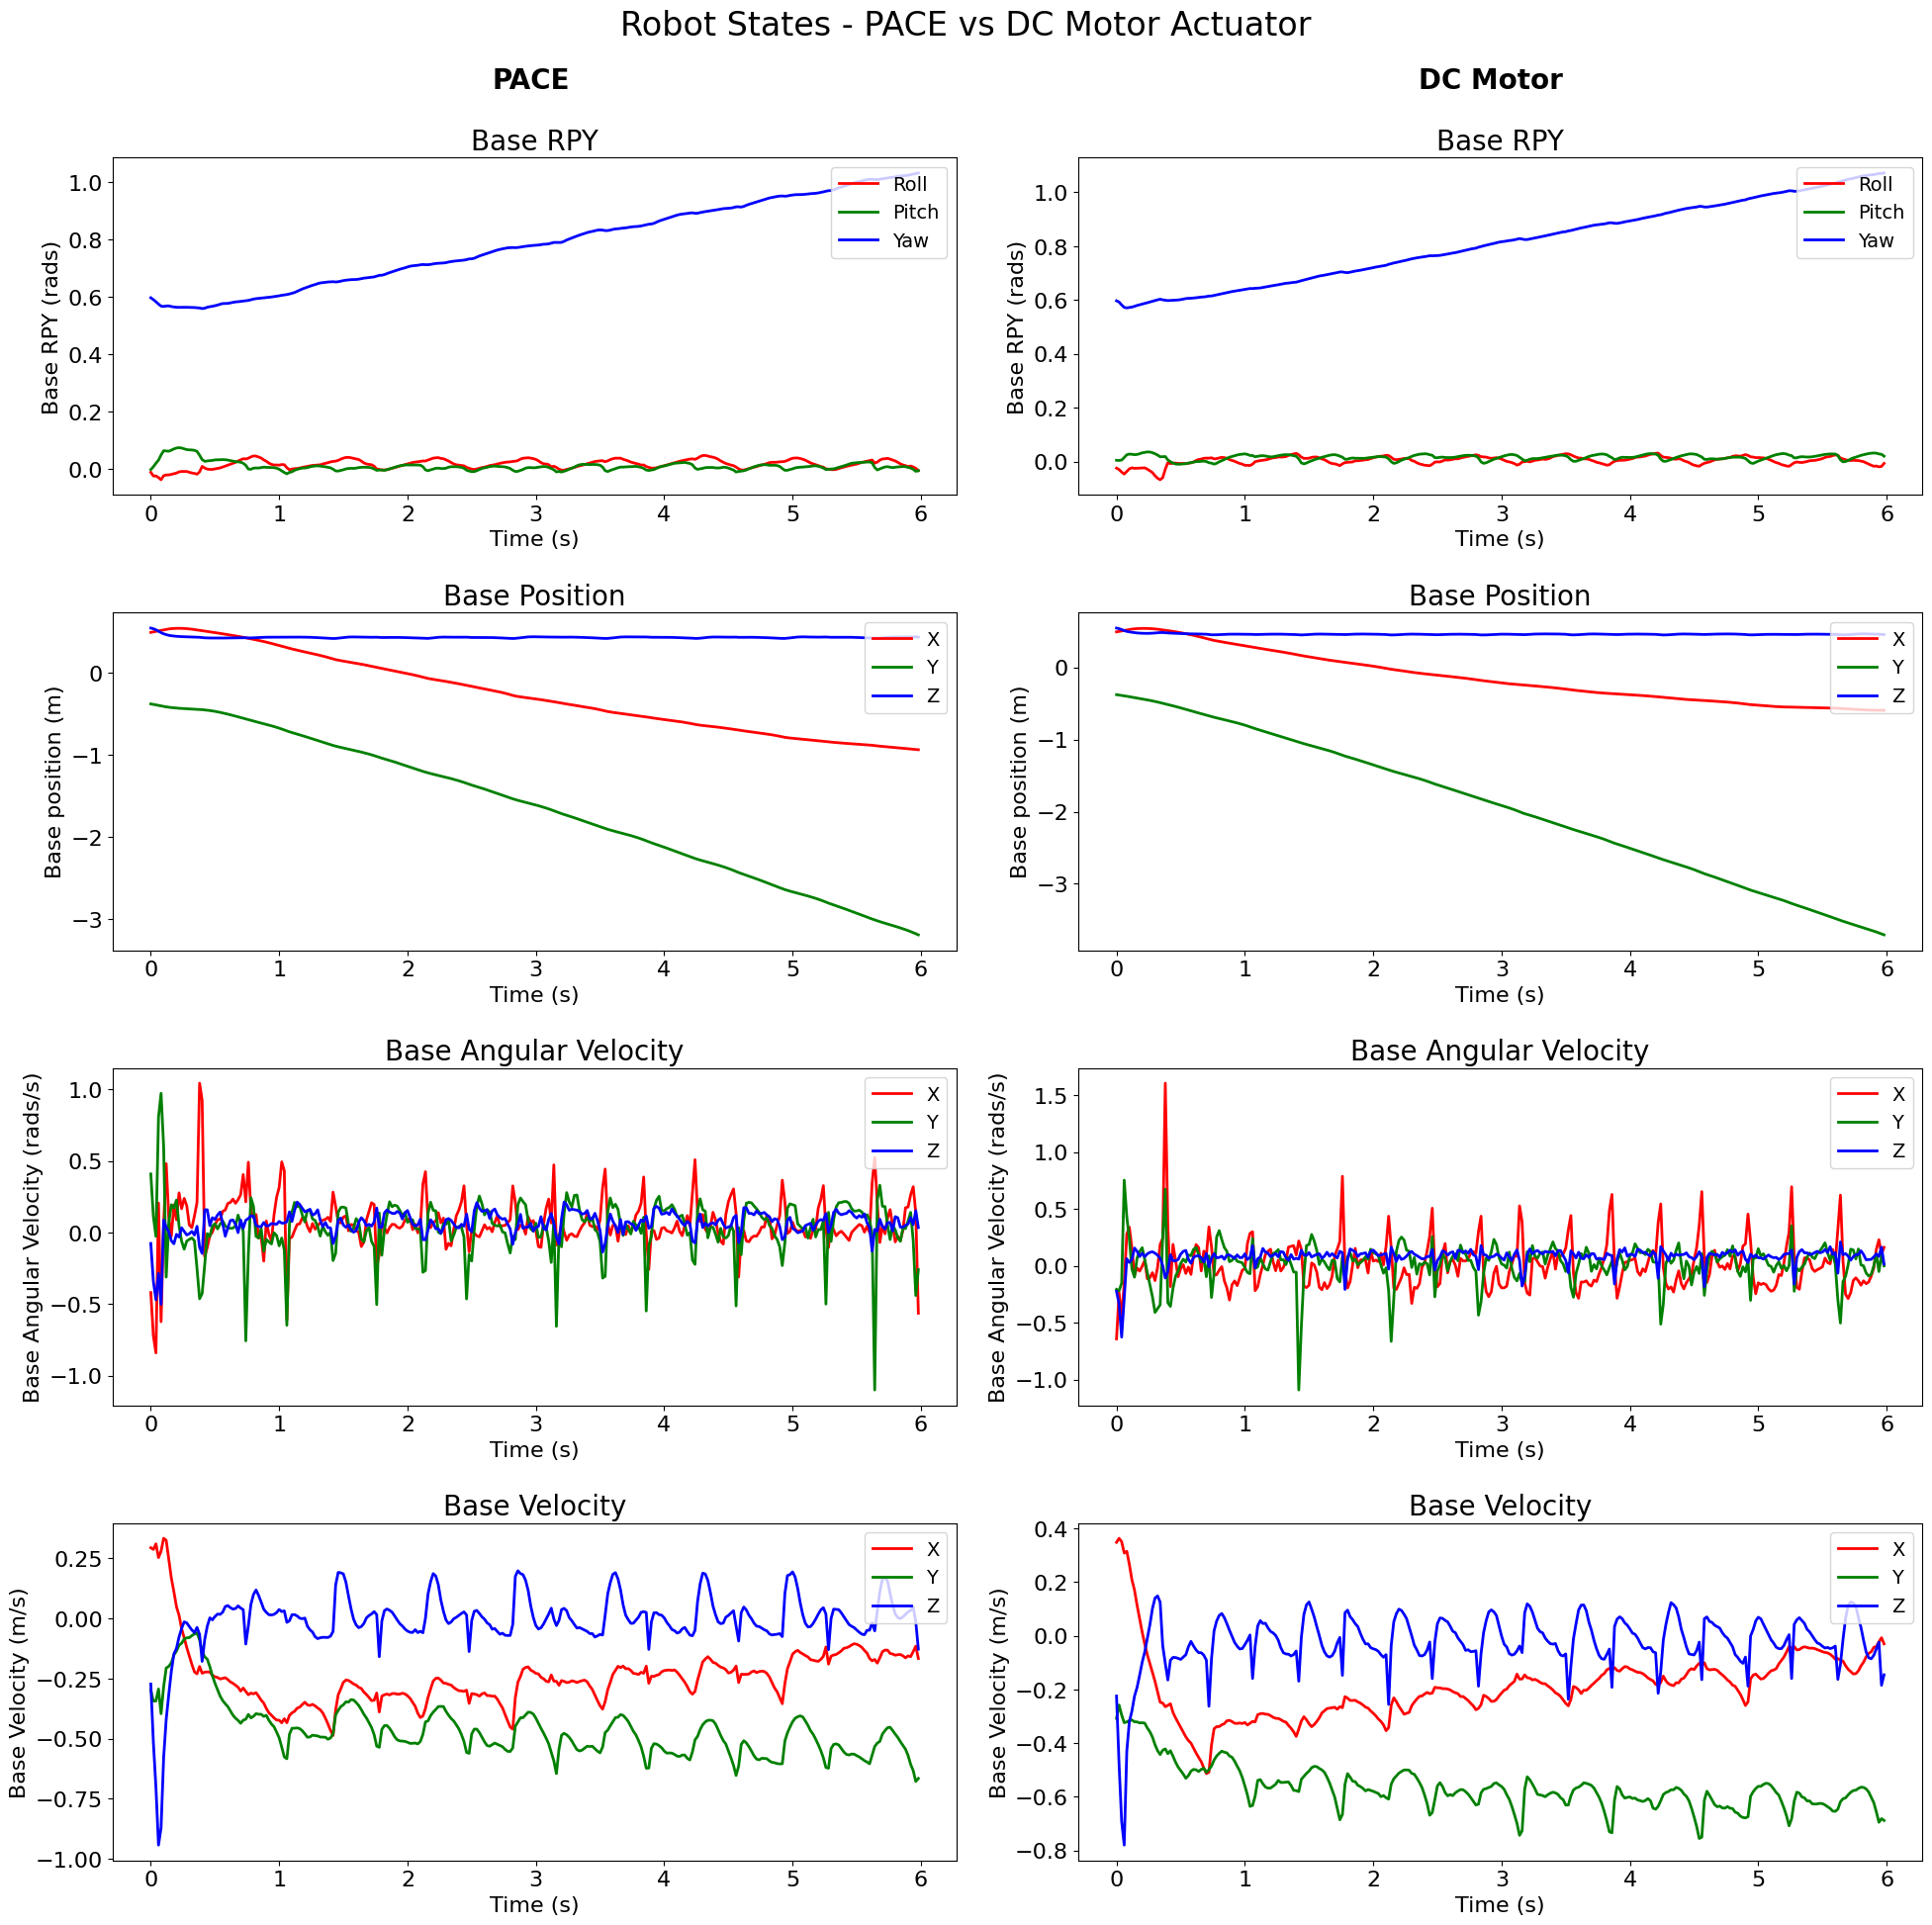

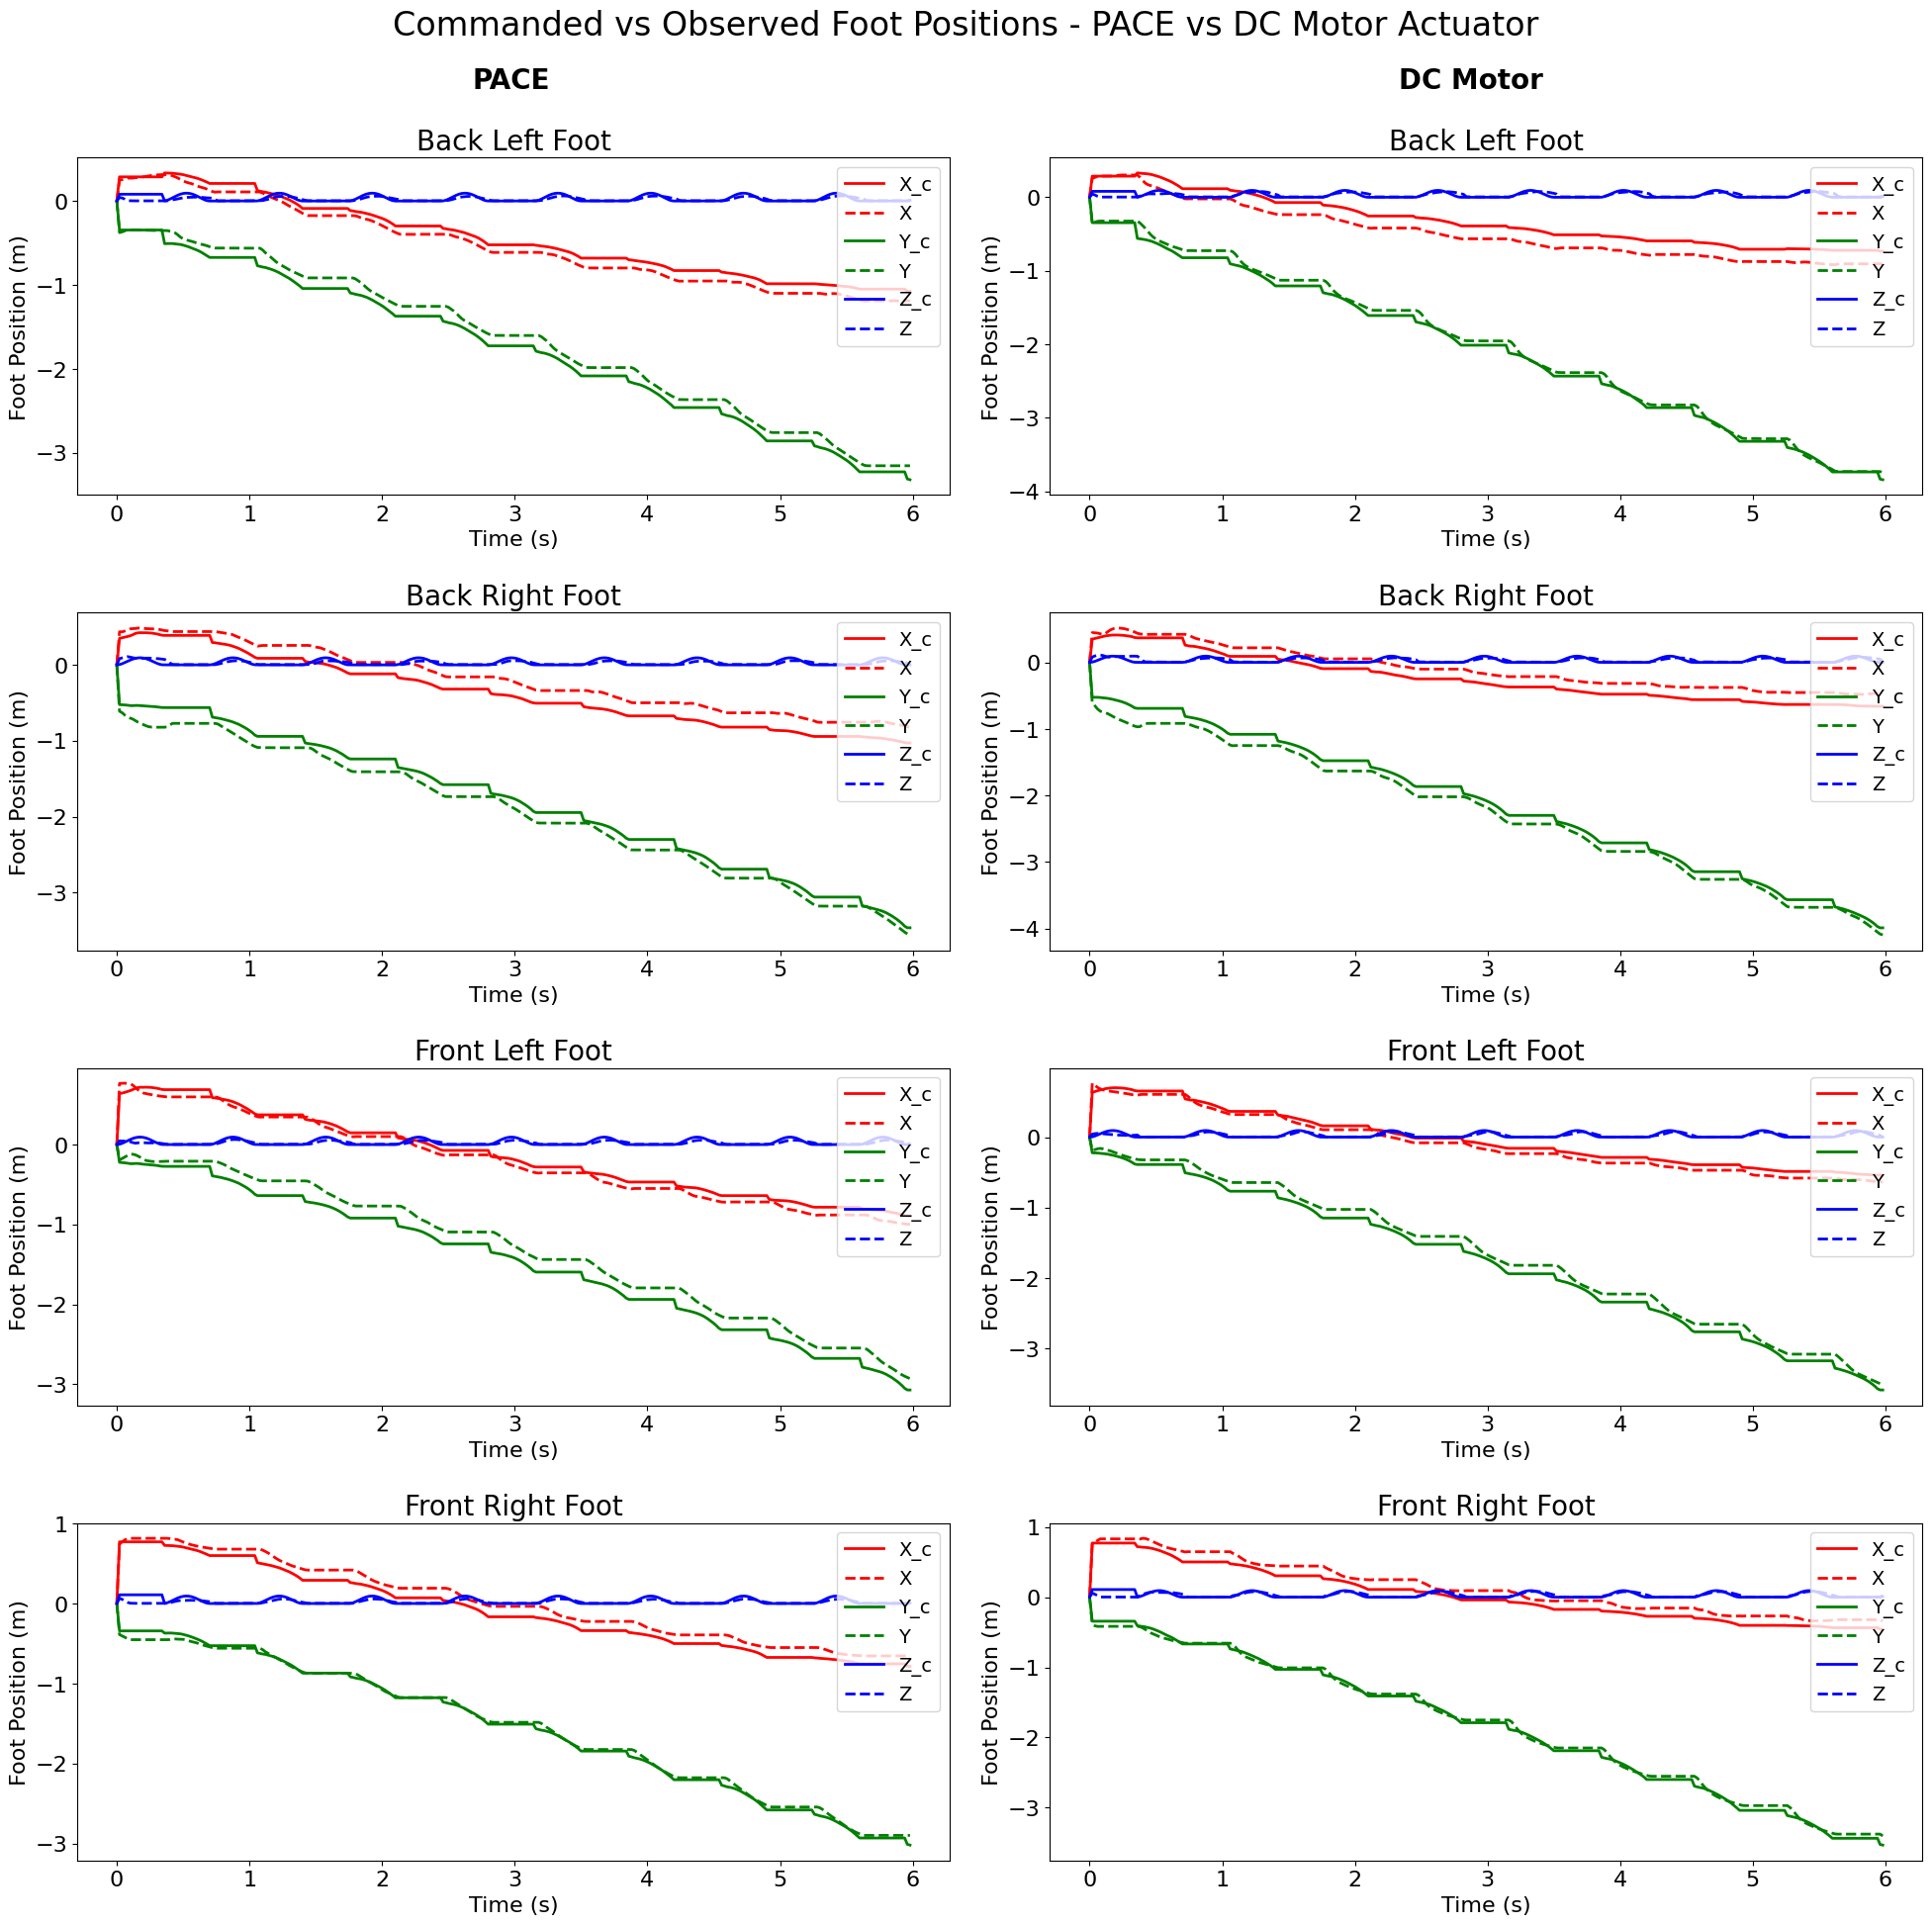

In [21]:
fig, ax = plt.subplots(4,2, figsize=(20, 20))

ax[0,0].plot(time_step[start:stop]/50.0, wrapped_rpy_pace[start:stop, 0], c='r')
ax[0,0].plot(time_step[start:stop]/50.0, wrapped_rpy_pace[start:stop, 1], c='g')
ax[0,0].plot(time_step[start:stop]/50.0, wrapped_rpy_pace[start:stop, 2], c='b')
ax[0,0].set_xlabel("Time (s)")
ax[0,0].set_ylabel("Base RPY (rads)")
ax[0,0].legend(['Roll', 'Pitch', 'Yaw'], loc='upper right')
ax[0,0].set_title("Base RPY")

ax[1,0].plot(time_step[start:stop]/50.0, root_pos_pace[start:stop, 0], c='r')
ax[1,0].plot(time_step[start:stop]/50.0, root_pos_pace[start:stop, 1], c='g')
ax[1,0].plot(time_step[start:stop]/50.0, root_pos_pace[start:stop, 2], c='b')
ax[1,0].set_xlabel("Time (s)")
ax[1,0].set_ylabel("Base position (m)")
ax[1,0].legend(['X', 'Y', 'Z'], loc='upper right')
ax[1,0].set_title("Base Position")

ax[2,0].plot(time_step[start:stop]/50.0, root_ang_vel_pace[start:stop, 0], c='r')
ax[2,0].plot(time_step[start:stop]/50.0, root_ang_vel_pace[start:stop, 1], c='g')
ax[2,0].plot(time_step[start:stop]/50.0, root_ang_vel_pace[start:stop, 2], c='b')
ax[2,0].set_xlabel("Time (s)")
ax[2,0].set_ylabel("Base Angular Velocity (rads/s)")
ax[2,0].legend(['X', 'Y', 'Z'], loc='upper right')
ax[2,0].set_title("Base Angular Velocity")

ax[3,0].plot(time_step[start:stop]/50.0, root_lin_vel_pace[start:stop, 0], c='r')
ax[3,0].plot(time_step[start:stop]/50.0, root_lin_vel_pace[start:stop, 1], c='g')
ax[3,0].plot(time_step[start:stop]/50.0, root_lin_vel_pace[start:stop, 2], c='b')
ax[3,0].set_xlabel("Time (s)")
ax[3,0].set_ylabel("Base Velocity (m/s)")
ax[3,0].legend(['X', 'Y', 'Z'], loc='upper right')
ax[3,0].set_title("Base Velocity")

ax[0,1].plot(time_step[start:stop]/50.0, wrapped_rpy_dc[start:stop, 0], c='r')
ax[0,1].plot(time_step[start:stop]/50.0, wrapped_rpy_dc[start:stop, 1], c='g')
ax[0,1].plot(time_step[start:stop]/50.0, wrapped_rpy_dc[start:stop, 2], c='b')
ax[0,1].set_xlabel("Time (s)")
ax[0,1].set_ylabel("Base RPY (rads)")
ax[0,1].legend(['Roll', 'Pitch', 'Yaw'], loc='upper right')
ax[0,1].set_title("Base RPY")

ax[1,1].plot(time_step[start:stop]/50.0, root_pos_dc[start:stop, 0], c='r')
ax[1,1].plot(time_step[start:stop]/50.0, root_pos_dc[start:stop, 1], c='g')
ax[1,1].plot(time_step[start:stop]/50.0, root_pos_dc[start:stop, 2], c='b')
ax[1,1].set_xlabel("Time (s)")
ax[1,1].set_ylabel("Base position (m)")
ax[1,1].legend(['X', 'Y', 'Z'], loc='upper right')
ax[1,1].set_title("Base Position")

ax[2,1].plot(time_step[start:stop]/50.0, root_ang_vel_dc[start:stop, 0], c='r')
ax[2,1].plot(time_step[start:stop]/50.0, root_ang_vel_dc[start:stop, 1], c='g')
ax[2,1].plot(time_step[start:stop]/50.0, root_ang_vel_dc[start:stop, 2], c='b')
ax[2,1].set_xlabel("Time (s)")
ax[2,1].set_ylabel("Base Angular Velocity (rads/s)")
ax[2,1].legend(['X', 'Y', 'Z'], loc='upper right')
ax[2,1].set_title("Base Angular Velocity")

ax[3,1].plot(time_step[start:stop]/50.0, root_lin_vel_dc[start:stop, 0], c='r')
ax[3,1].plot(time_step[start:stop]/50.0, root_lin_vel_dc[start:stop, 1], c='g')
ax[3,1].plot(time_step[start:stop]/50.0, root_lin_vel_dc[start:stop, 2], c='b')
ax[3,1].set_xlabel("Time (s)")
ax[3,1].set_ylabel("Base Velocity (m/s)")
ax[3,1].legend(['X', 'Y', 'Z'], loc='upper right')
ax[3,1].set_title("Base Velocity")

fig.suptitle("Robot States - PACE vs DC Motor Actuator", fontsize=24)
fig.text(0.28, 0.94, "PACE", ha='center', fontsize=20, fontweight='bold')
fig.text(0.765, 0.94, "DC Motor", ha='center', fontsize=20, fontweight='bold')
plt.tight_layout(pad=1.5, rect=[0, 0, 1, 0.97])
plt.savefig(f"{save_folder}/sim_states.png")
plt.show()

fig, ax = plt.subplots(4,2, figsize=(20, 20))

ax[0,0].plot(time_step[start:stop]/50.0, commanded_fp_pace[start:stop, 0], c='r')
ax[0,0].plot(time_step[start:stop]/50.0, observed_fp_pace[start:stop, 0], c='r', linestyle='dashed')
ax[0,0].plot(time_step[start:stop]/50.0, commanded_fp_pace[start:stop, 1], c='g')
ax[0,0].plot(time_step[start:stop]/50.0, observed_fp_pace[start:stop, 1], c='g', linestyle='dashed')
ax[0,0].plot(time_step[start:stop]/50.0, commanded_fp_pace[start:stop, 2], c='b')
ax[0,0].plot(time_step[start:stop]/50.0, observed_fp_pace[start:stop, 2], c='b', linestyle='dashed')
ax[0,0].set_xlabel("Time (s)")
ax[0,0].set_ylabel("Foot Position (m)")
ax[0,0].legend(['X_c', 'X', 'Y_c', 'Y', 'Z_c', 'Z'], loc='upper right')
ax[0,0].set_title("Back Left Foot")

ax[1,0].plot(time_step[start:stop]/50.0, commanded_fp_pace[start:stop, 3], c='r')
ax[1,0].plot(time_step[start:stop]/50.0, observed_fp_pace[start:stop, 3], c='r', linestyle='dashed')
ax[1,0].plot(time_step[start:stop]/50.0, commanded_fp_pace[start:stop, 4], c='g')
ax[1,0].plot(time_step[start:stop]/50.0, observed_fp_pace[start:stop, 4], c='g', linestyle='dashed')
ax[1,0].plot(time_step[start:stop]/50.0, commanded_fp_pace[start:stop, 5], c='b')
ax[1,0].plot(time_step[start:stop]/50.0, observed_fp_pace[start:stop, 5], c='b', linestyle='dashed')
ax[1,0].set_xlabel("Time (s)")
ax[1,0].set_ylabel("Foot Position (m)")
ax[1,0].legend(['X_c', 'X', 'Y_c', 'Y', 'Z_c', 'Z'], loc='upper right')
ax[1,0].set_title("Back Right Foot")

ax[2,0].plot(time_step[start:stop]/50.0, commanded_fp_pace[start:stop, 6], c='r')
ax[2,0].plot(time_step[start:stop]/50.0, observed_fp_pace[start:stop, 6], c='r', linestyle='dashed')
ax[2,0].plot(time_step[start:stop]/50.0, commanded_fp_pace[start:stop, 7], c='g')
ax[2,0].plot(time_step[start:stop]/50.0, observed_fp_pace[start:stop, 7], c='g', linestyle='dashed')
ax[2,0].plot(time_step[start:stop]/50.0, commanded_fp_pace[start:stop, 8], c='b')
ax[2,0].plot(time_step[start:stop]/50.0, observed_fp_pace[start:stop, 8], c='b', linestyle='dashed')
ax[2,0].set_xlabel("Time (s)")
ax[2,0].set_ylabel("Foot Position (m)")
ax[2,0].legend(['X_c', 'X', 'Y_c', 'Y', 'Z_c', 'Z'], loc='upper right')
ax[2,0].set_title("Front Left Foot")

ax[3,0].plot(time_step[start:stop]/50.0, commanded_fp_pace[start:stop, 9], c='r')
ax[3,0].plot(time_step[start:stop]/50.0, observed_fp_pace[start:stop, 9], c='r', linestyle='dashed')
ax[3,0].plot(time_step[start:stop]/50.0, commanded_fp_pace[start:stop, 10], c='g')
ax[3,0].plot(time_step[start:stop]/50.0, observed_fp_pace[start:stop, 10], c='g', linestyle='dashed')
ax[3,0].plot(time_step[start:stop]/50.0, commanded_fp_pace[start:stop, 11], c='b')
ax[3,0].plot(time_step[start:stop]/50.0, observed_fp_pace[start:stop, 11], c='b', linestyle='dashed')
ax[3,0].set_xlabel("Time (s)")
ax[3,0].set_ylabel("Foot Position (m)")
ax[3,0].legend(['X_c', 'X', 'Y_c', 'Y', 'Z_c', 'Z'], loc='upper right')
ax[3,0].set_title("Front Right Foot")

ax[0,1].plot(time_step[start:stop]/50.0, commanded_fp_dc[start:stop, 0], c='r')
ax[0,1].plot(time_step[start:stop]/50.0, observed_fp_dc[start:stop, 0], c='r', linestyle='dashed')
ax[0,1].plot(time_step[start:stop]/50.0, commanded_fp_dc[start:stop, 1], c='g')
ax[0,1].plot(time_step[start:stop]/50.0, observed_fp_dc[start:stop, 1], c='g', linestyle='dashed')
ax[0,1].plot(time_step[start:stop]/50.0, commanded_fp_dc[start:stop, 2], c='b')
ax[0,1].plot(time_step[start:stop]/50.0, observed_fp_dc[start:stop, 2], c='b', linestyle='dashed')
ax[0,1].set_xlabel("Time (s)")
ax[0,1].set_ylabel("Foot Position (m)")
ax[0,1].legend(['X_c', 'X', 'Y_c', 'Y', 'Z_c', 'Z'], loc='upper right')
ax[0,1].set_title("Back Left Foot")

ax[1,1].plot(time_step[start:stop]/50.0, commanded_fp_dc[start:stop, 3], c='r')
ax[1,1].plot(time_step[start:stop]/50.0, observed_fp_dc[start:stop, 3], c='r', linestyle='dashed')
ax[1,1].plot(time_step[start:stop]/50.0, commanded_fp_dc[start:stop, 4], c='g')
ax[1,1].plot(time_step[start:stop]/50.0, observed_fp_dc[start:stop, 4], c='g', linestyle='dashed')
ax[1,1].plot(time_step[start:stop]/50.0, commanded_fp_dc[start:stop, 5], c='b')
ax[1,1].plot(time_step[start:stop]/50.0, observed_fp_dc[start:stop, 5], c='b', linestyle='dashed')
ax[1,1].set_xlabel("Time (s)")
ax[1,1].set_ylabel("Foot Position (m)")
ax[1,1].legend(['X_c', 'X', 'Y_c', 'Y', 'Z_c', 'Z'], loc='upper right')
ax[1,1].set_title("Back Right Foot")

ax[2,1].plot(time_step[start:stop]/50.0, commanded_fp_dc[start:stop, 6], c='r')
ax[2,1].plot(time_step[start:stop]/50.0, observed_fp_dc[start:stop, 6], c='r', linestyle='dashed')
ax[2,1].plot(time_step[start:stop]/50.0, commanded_fp_dc[start:stop, 7], c='g')
ax[2,1].plot(time_step[start:stop]/50.0, observed_fp_dc[start:stop, 7], c='g', linestyle='dashed')
ax[2,1].plot(time_step[start:stop]/50.0, commanded_fp_dc[start:stop, 8], c='b')
ax[2,1].plot(time_step[start:stop]/50.0, observed_fp_dc[start:stop, 8], c='b', linestyle='dashed')
ax[2,1].set_xlabel("Time (s)")
ax[2,1].set_ylabel("Foot Position (m)")
ax[2,1].legend(['X_c', 'X', 'Y_c', 'Y', 'Z_c', 'Z'], loc='upper right')
ax[2,1].set_title("Front Left Foot")

ax[3,1].plot(time_step[start:stop]/50.0, commanded_fp_dc[start:stop, 9], c='r')
ax[3,1].plot(time_step[start:stop]/50.0, observed_fp_dc[start:stop, 9], c='r', linestyle='dashed')
ax[3,1].plot(time_step[start:stop]/50.0, commanded_fp_dc[start:stop, 10], c='g')
ax[3,1].plot(time_step[start:stop]/50.0, observed_fp_dc[start:stop, 10], c='g', linestyle='dashed')
ax[3,1].plot(time_step[start:stop]/50.0, commanded_fp_dc[start:stop, 11], c='b')
ax[3,1].plot(time_step[start:stop]/50.0, observed_fp_dc[start:stop, 11], c='b', linestyle='dashed')
ax[3,1].set_xlabel("Time (s)")
ax[3,1].set_ylabel("Foot Position (m)")
ax[3,1].legend(['X_c', 'X', 'Y_c', 'Y', 'Z_c', 'Z'], loc='upper right')
ax[3,1].set_title("Front Right Foot")

fig.suptitle("Commanded vs Observed Foot Positions - PACE vs DC Motor Actuator", fontsize=24)
fig.text(0.27, 0.94, "PACE", ha='center', fontsize=20, fontweight='bold')
fig.text(0.755, 0.94, "DC Motor", ha='center', fontsize=20, fontweight='bold')
plt.tight_layout(pad=1.5, rect=[0, 0, 1, 0.97])
plt.savefig(f"{save_folder}/sim_foot_positions.png")
plt.show()